# Experiment 1

Implement a program to acquire and display an image. Demonstrate the process of image sensing and acquisition, and explain the components involved in an image processing system.

### Theory
### Image Sensing and Acquisition
Image acquisition is the first and fundamental step in digital image processing. It involves capturing a real-world scene using a sensing device and converting it into a digital image suitable for computer processing.

The process consists of:
1. Illumination of the scene  
2. Sensing of reflected or transmitted energy  
3. Conversion of energy into electrical signals  
4. Digitization of signals into pixel values  

### Image Acquisition Process

1. Illumination Source  
Provides energy (visible light, infrared, X-ray, etc.) to illuminate the object.

2. Object/Scene  
Reflects or transmits the incident energy.

3. Image Sensor  
Captures the reflected energy using devices such as:  
CCD (Charge Coupled Device)  
CMOS (Complementary Metal Oxide Semiconductor)

4. Analog Signal Generation  
The sensor converts energy into analog electrical signals.

5. Analog-to-Digital Converter (ADC)  
Converts analog signals into digital pixel values.

6. Digital Image Formation  
The output is a matrix of intensity values representing the image.

### Algorithm

1. Import required libraries.  
2. Read the input image using image acquisition function.  
3. Display the acquired image.  
4. Wait for a key press and close display window.

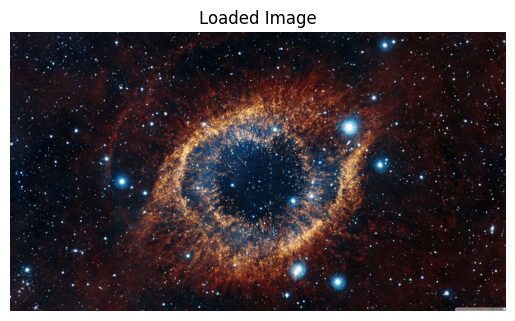

In [1]:
import cv2
import matplotlib.pyplot as plt

# Step 1: Acquire the image from file
image = cv2.imread('image.jpg')

# Step 2: Check if image is successfully loaded
if image is None:
    print("Error: Image not found")
else:
    # Step 3: Convert BGR → RGB (VERY important)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Step 4: Display the loaded image
    plt.imshow(image_rgb)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()

# Experiment 2

Develop a program to perform sampling and quantization on a given image. Visualize the effects of different sampling rates and quantization levels on image quality.

### Theory
### Sampling
Sampling is the process of reducing the spatial resolution of an image by selecting a subset of pixels from the original image.

- High sampling rate → more pixels → better spatial detail  
- Low sampling rate → fewer pixels → loss of fine details (aliasing)  

Sampling affects the spatial resolution of the image.

### Quantization
Quantization is the process of reducing the number of intensity levels used to represent pixel values.

- High quantization levels → smooth intensity transitions  
- Low quantization levels → visible intensity jumps (false contouring)  

Quantization affects the gray-level resolution of the image.

### Algorithm

1. Read the input image.  
2. Convert the image to grayscale.  
3. Perform sampling by down sampling the image at different rates.  
4. Perform quantization using different gray-level values.  
5. Display original and processed images for comparison.

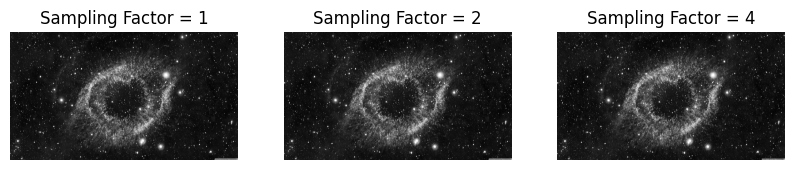

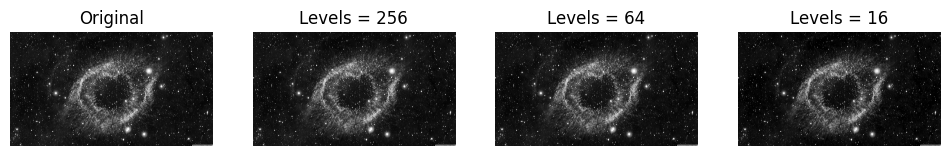

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not found")

# Function for sampling
def sampling(img, factor):
    return img[::factor, ::factor]

# Function for quantization
def quantization(img, levels):
    img_norm = img / 255.0
    img_quant = np.floor(img_norm * levels) / levels
    return (img_quant * 255).astype(np.uint8)

# Sampling factors and quantization levels
sampling_factors = [1, 2, 4]
quant_levels = [256, 64, 16]

# Display sampling results
plt.figure(figsize=(10, 4))
for i, f in enumerate(sampling_factors):
    sampled_img = sampling(image, f)
    sampled_img = cv2.resize(sampled_img, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    plt.subplot(1, 3, i+1)
    plt.imshow(sampled_img, cmap='gray')
    plt.title(f'Sampling Factor = {f}')
    plt.axis('off')
plt.show()

# Display quantization results with original image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, q in enumerate(quant_levels):
    quant_img = quantization(image, q)
    plt.subplot(1, 4, i+2)
    plt.imshow(quant_img, cmap='gray')
    plt.title(f'Levels = {q}')
    plt.axis('off')

plt.show()

# Experiment 3

Implement image enhancement techniques in the spatial domain, including contrast stretching and histogram equalization. Compare the results before and after enhancement.

### Theory

Image enhancement in the spatial domain operates directly on pixel intensities to improve the visual appearance of an image. Contrast stretching increases the dynamic range of intensity values, while histogram equalization redistributes intensity levels to enhance global contrast.

### Algorithm

1. Read the input image and convert it to grayscale.  
2. Apply contrast stretching using minimum and maximum intensity values.  
3. Perform histogram equalization on the image.  
4. Display original and enhanced images.  